Machine Learning Task: HR Attrition
Prediction (Classification)

🧠 Problem Statement

Employee attrition is a critical issue for organizations, leading to increased hiring costs,
productivity loss, and reduced employee morale.
In this project, the goal is to build a Machine Learning classification model that predicts
whether an employee will leave the company (Attrition: Yes/No) based on features such as:

● Age

● Salary

● Job Role

● Job Satisfaction

● Work Experience

● Overtime

● Work-Life Balance

● Department

Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting employee attrition.

Objective

The objective of this task is to:

● Understand and explore the HR dataset

● Perform data preprocessing (missing values, duplicates, outliers)

● Conduct Exploratory Data Analysis (EDA)

● Apply encoding and feature scaling

● Train multiple classification algorithms

● Evaluate models using classification metrics

● Perform cross-validation and hyperparameter tuning

● Select the best-performing model

Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE

Load the Dataset

In [ ]:
df = pd.read_csv("HR-Employee-Attrition.csv")

Check Dataset

In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

Handle Missing Values

In [ ]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

Remove Duplicate Records

In [ ]:
df = df.drop_duplicates()

Perform Univariate Analysis

● Distribution of numerical features

● Count plots for categorical features

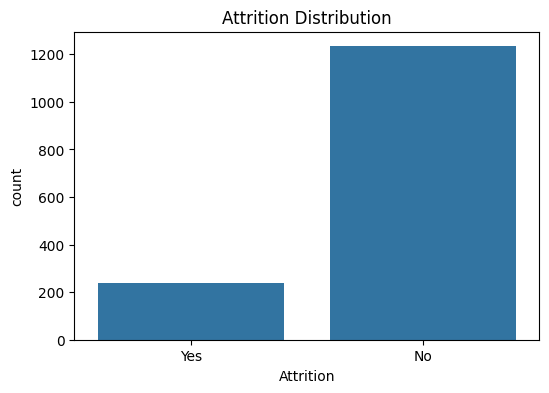

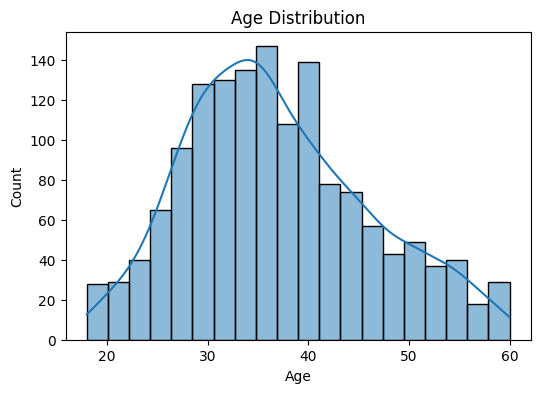

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Attrition", data=df)
plt.title("Attrition Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

Perform Bivariate Analysis

● Attrition vs categorical features

● Attrition vs numerical features

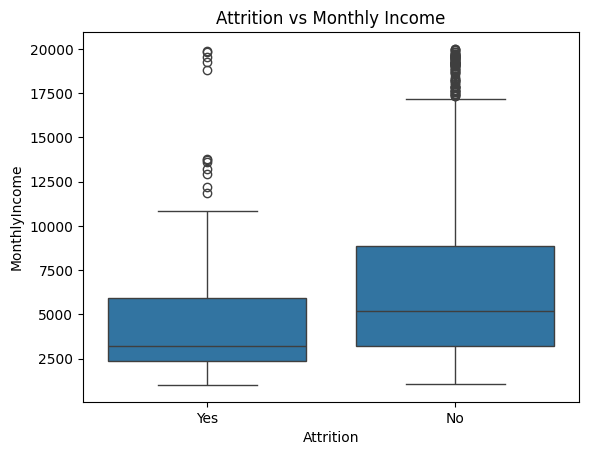

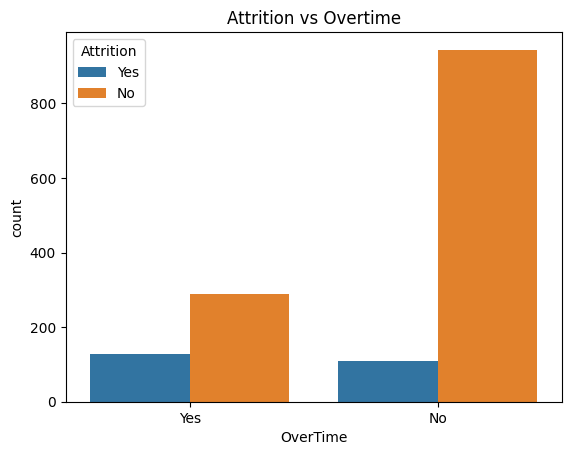

In [ ]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Attrition vs Monthly Income")
plt.show()

sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Attrition vs Overtime")
plt.show()

Generate Correlation Heatmap

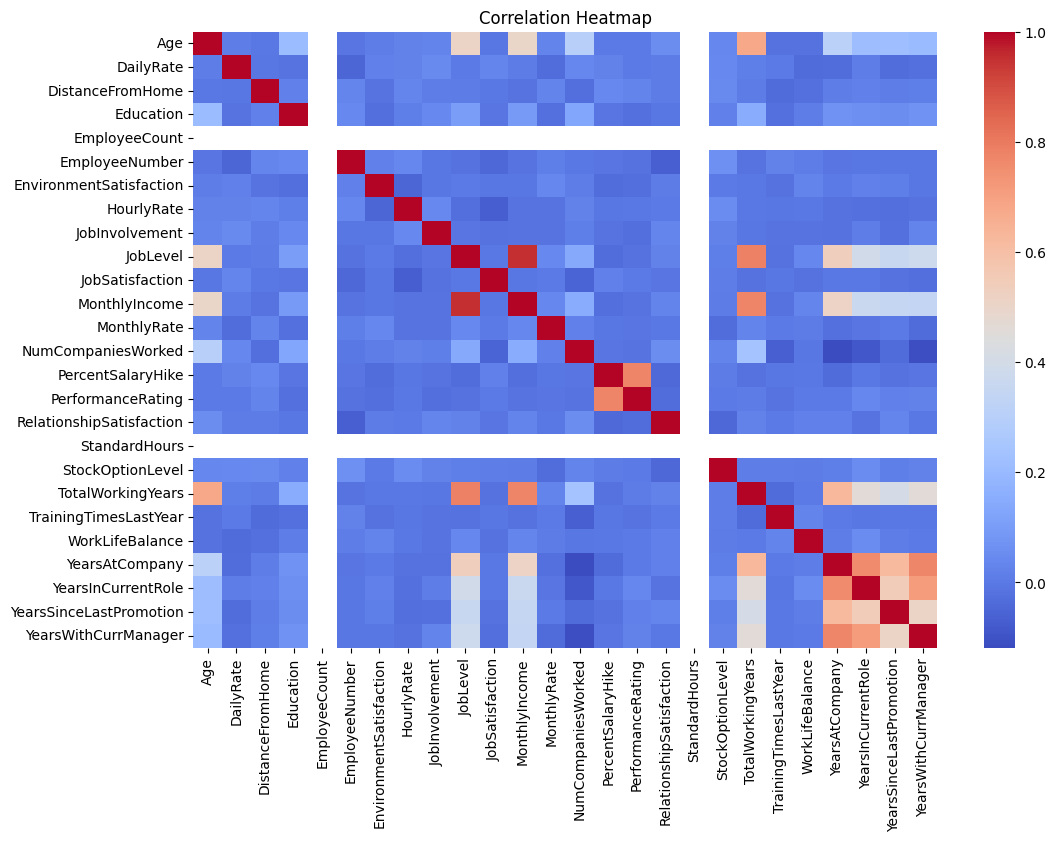

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Detect and Handle Outliers

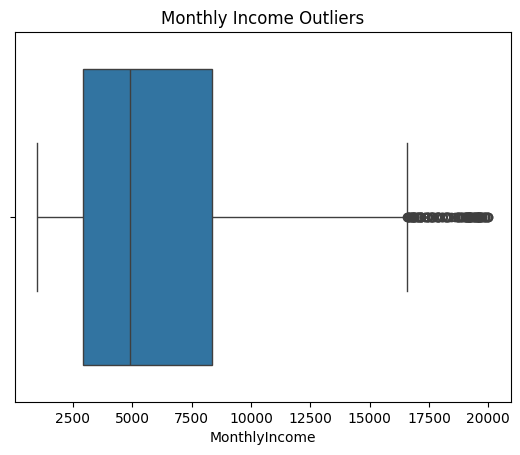

In [ ]:
sns.boxplot(x=df["MonthlyIncome"])
plt.title("Monthly Income Outliers")
plt.show()

Apply Encoding

● Label Encoding

● One-Hot Encoding

In [ ]:
# Label encode binary columns
le = LabelEncoder()
df["Attrition"] = le.fit_transform(df["Attrition"])  # Yes=1, No=0
df["OverTime"] = le.fit_transform(df["OverTime"])
df["Gender"] = le.fit_transform(df["Gender"])

# One-hot encode categorical features
df = pd.get_dummies(df, columns=["Department","JobRole","BusinessTravel","EducationField","MaritalStatus"], drop_first=True)

Apply Scaling

● StandardScaler / MinMaxScaler

In [ ]:
scaler = StandardScaler()
num_cols = ["Age","DailyRate","DistanceFromHome","MonthlyIncome","PercentSalaryHike","TotalWorkingYears","YearsAtCompany"]
df[num_cols] = scaler.fit_transform(df[num_cols])

Separate Features and Target Variable

● X → Features

● y → Attrition

In [ ]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

Perform Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
X = pd.get_dummies(X, drop_first=True)

Balance data : SMOTE

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

Train Classification Models

● Logistic Regression

● Decision Tree Classifier

● Random Forest Classifier

● KNN Classifier

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    }
    print(f"\n{name} Classification Report:\n", classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.90      0.90       370
           1       0.46      0.45      0.45        71

    accuracy                           0.83       441
   macro avg       0.68      0.67      0.67       441
weighted avg       0.82      0.83      0.82       441


Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.79      0.82       370
           1       0.23      0.32      0.27        71

    accuracy                           0.72       441
   macro avg       0.54      0.56      0.55       441
weighted avg       0.76      0.72      0.73       441


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       370
           1       0.59      0.31      0.41        71

    accuracy                           0.85       441
   ma

Evaluate Models Using

● Accuracy

● Precision

● Recall

● F1 Score

● ROC-AUC Score

● Confusion Matrix

In [ ]:
results_df = pd.DataFrame(results).T
print("\nModel Comparison:\n", results_df)


Model Comparison:
                      Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.825397   0.457143  0.450704  0.453901  0.774800
Decision Tree        0.716553   0.230000  0.323944  0.269006  0.557918
Random Forest        0.854875   0.594595  0.309859  0.407407  0.723810
KNN                  0.596372   0.179641  0.422535  0.252101  0.528302


Perform Cross Validation

In [ ]:
rf = RandomForestClassifier(random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="f1")
print("Random Forest CV F1 Scores:", cv_scores)

Random Forest CV F1 Scores: [0.18518519 0.31034483 0.37288136 0.18867925 0.18867925]


Apply Hyperparameter Tuning

● GridSearchCV

● RandomizedSearchCV

In [ ]:
param_grid = {
    "n_estimators": [100,200],
    "max_depth": [None,10,20],
    "min_samples_split": [2,5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring="f1")
grid.fit(X_train, y_train)
print("Best RF Params:", grid.best_params_)

Best RF Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


Compare Model Performance


● Create comparison table

● Identify best model


Model Comparison:
                      Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.825397   0.457143  0.450704  0.453901  0.774800
Decision Tree        0.716553   0.230000  0.323944  0.269006  0.557918
Random Forest        0.854875   0.594595  0.309859  0.407407  0.723810
KNN                  0.596372   0.179641  0.422535  0.252101  0.528302


<Figure size 1000x600 with 0 Axes>

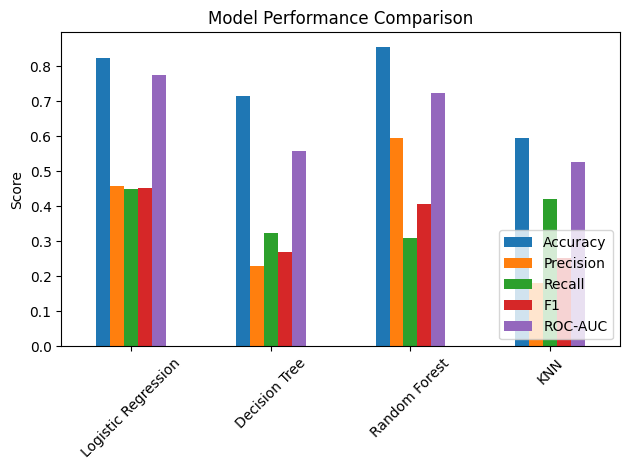


🏆 Best Model based on F1 Score: Logistic Regression


In [ ]:
# After training and storing results in the 'results' dictionary:
results_df = pd.DataFrame(results).T

# Display comparison table
print("\nModel Comparison:\n", results_df)

# Plot comparison for visual clarity
plt.figure(figsize=(10,6))
results_df[["Accuracy","Precision","Recall","F1","ROC-AUC"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Identify best model based on F1 Score (or ROC-AUC)
best_model_name = results_df["F1"].idxmax()
print(f"\n🏆 Best Model based on F1 Score: {best_model_name}")

Select Best Model

● Based on metrics

● Business interpretation


Model Comparison:
                      Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.825397   0.457143  0.450704  0.453901  0.774800
Decision Tree        0.716553   0.230000  0.323944  0.269006  0.557918
Random Forest        0.854875   0.594595  0.309859  0.407407  0.723810
KNN                  0.596372   0.179641  0.422535  0.252101  0.528302


<Figure size 1000x600 with 0 Axes>

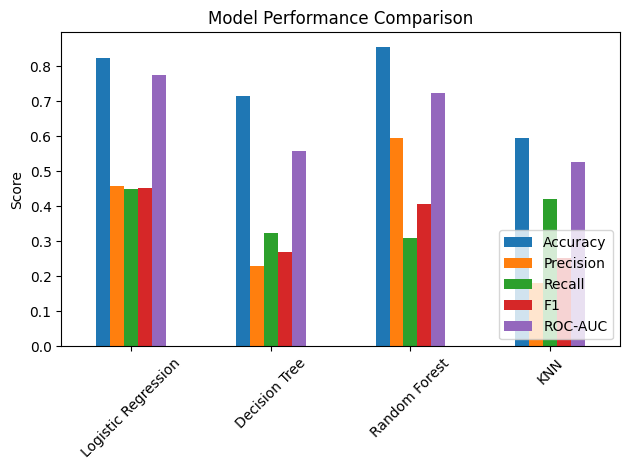


🏆 Best Model based on F1 Score: Logistic Regression

Top Features Influencing Attrition (Logistic Regression):
 BusinessTravel_Travel_Frequently    1.452758
Department_Sales                    1.368856
MaritalStatus_Single                1.063794
JobRole_Laboratory Technician       1.040143
JobRole_Sales Executive             0.987804
JobInvolvement                     -0.917709
WorkLifeBalance                    -0.840533
EducationField_Marketing            0.836923
OverTime                            0.767499
StockOptionLevel                   -0.717223
dtype: float64


In [ ]:


# Assuming 'results' dictionary already contains metrics for each model
results_df = pd.DataFrame(results).T

# Show comparison table
print("\nModel Comparison:\n", results_df)

# Plot comparison for visual clarity
plt.figure(figsize=(10,6))
results_df[["Accuracy","Precision","Recall","F1","ROC-AUC"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Select best model based on F1 Score (you can also use ROC-AUC if preferred)
best_model_name = results_df["F1"].idxmax()
print(f"\n🏆 Best Model based on F1 Score: {best_model_name}")

# Business interpretation: feature importance
if best_model_name == "Random Forest":
    best_model = models["Random Forest"]
    importances = best_model.feature_importances_
    feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)
    print("\nTop Features Influencing Attrition (Random Forest):\n", feat_importances.head(10))

elif best_model_name == "Logistic Regression":
    best_model = models["Logistic Regression"]
    coef = best_model.coef_[0]
    feat_importances = pd.Series(coef, index=X.columns).sort_values(key=abs, ascending=False)
    print("\nTop Features Influencing Attrition (Logistic Regression):\n", feat_importances.head(10))

Final Insights

● Key factors influencing attrition

● Business recommendations

In [ ]:
best_model = grid.best_estimator_
importances = best_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print("\nTop Features Influencing Attrition:\n", feat_importances.head(10))


Top Features Influencing Attrition:
 StockOptionLevel        0.070999
MaritalStatus_Single    0.062542
JobLevel                0.049893
YearsWithCurrManager    0.043101
MonthlyIncome           0.040342
DistanceFromHome        0.038166
Age                     0.037284
Department_Sales        0.037226
JobSatisfaction         0.035477
YearsAtCompany          0.033572
dtype: float64
